In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your cleaned dataset
emissions = pd.read_csv("emissions_cleaned.csv")

# Numerical columns
num_cols = [
    'Engine_size_L',
    'Fuel_consumption_city_L_per_100km', 'Fuel_consumption_hwy_L_per_100km',
    'Fuel_consumption_comb_L_per_100km', 'Fuel_consumption_comb_mpg'
]


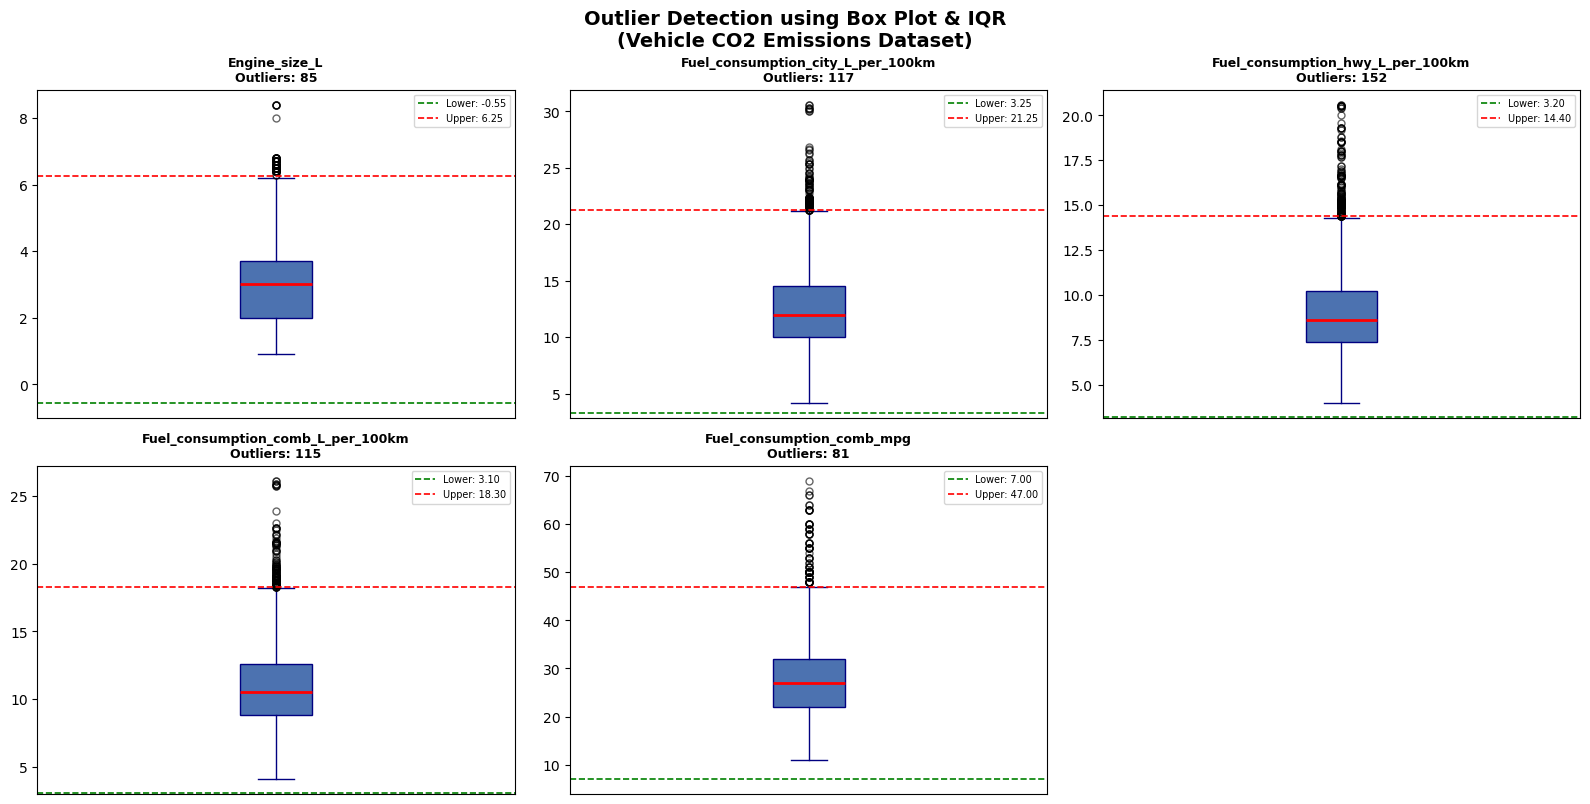

In [2]:

# Box Plots 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1 = emissions[col].quantile(0.25)
    Q3 = emissions[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((emissions[col] < lower) | (emissions[col] > upper)).sum()

    axes[i].boxplot(emissions[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange', markersize=5, alpha=0.6),
                    whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'))

    axes[i].axhline(lower, color='green', linestyle='--', linewidth=1.2, label=f'Lower: {lower:.2f}')
    axes[i].axhline(upper, color='red',   linestyle='--', linewidth=1.2, label=f'Upper: {upper:.2f}')

    axes[i].set_title(f'{col}\nOutliers: {outlier_count}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xticks([])

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection using Box Plot & IQR\n(Vehicle CO2 Emissions Dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
for col in num_cols:
    Q1 = emissions[col].quantile(0.25)
    Q3 = emissions[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((emissions[col] < lower) | (emissions[col] > upper)).sum()
    print(f"{col}: {count} outliers ({round(count/len(emissions)*100, 2)}%)")

Engine_size_L: 85 outliers (1.63%)
Fuel_consumption_city_L_per_100km: 117 outliers (2.24%)
Fuel_consumption_hwy_L_per_100km: 152 outliers (2.92%)
Fuel_consumption_comb_L_per_100km: 115 outliers (2.21%)
Fuel_consumption_comb_mpg: 81 outliers (1.55%)


In [4]:
df = emissions.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Before: {len(emissions)} rows")
print(f"After:  {len(df)} rows")
print(f"Removed: {len(emissions) - len(df)} rows")

Before: 5214 rows
After:  4805 rows
Removed: 409 rows


In [5]:

df = df[['Engine_size_L', 'Cylinders', 'Fuel_type','CO2_emissions_g_per_km']]

In [6]:
df.head()

,Engine_size_L,Cylinders,Fuel_type,CO2_emissions_g_per_km
0,2.0,4,electricity,196
1,2.4,4,electricity,221
3,3.5,6,electricity,255
4,3.5,6,electricity,244
5,3.5,6,electricity,230


In [7]:
df.shape

(4805, 4)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ct = ColumnTransformer(transformers=[("encoder", OneHotEncoder(), ['Fuel_type'])], 
                       remainder="passthrough")

ct.fit(df)

# Get all feature names automatically
feature_names = ct.get_feature_names_out()

# Clean up the names (removes "encoder__" and "remainder__" prefixes)
feature_names = [name.replace("encoder__", "").replace("remainder__", "") 
                 for name in feature_names]

df = pd.DataFrame(ct.transform(df), columns=feature_names)



In [9]:
df.head()

,Fuel_type_diesel,Fuel_type_electricity,Fuel_type_ethanol,Fuel_type_gasoline,Fuel_type_natural gas,Engine_size_L,Cylinders,CO2_emissions_g_per_km
0,0.0,1.0,0.0,0.0,0.0,2.0,4.0,196.0
1,0.0,1.0,0.0,0.0,0.0,2.4,4.0,221.0
2,0.0,1.0,0.0,0.0,0.0,3.5,6.0,255.0
3,0.0,1.0,0.0,0.0,0.0,3.5,6.0,244.0
4,0.0,1.0,0.0,0.0,0.0,3.5,6.0,230.0


In [ ]:
# save the processed dataframe to a CSV file
df.to_csv('processed_emissions1.csv', index=False)